In [35]:
import numpy as np 
import xarray as xr 
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable

## Ground truth phase map

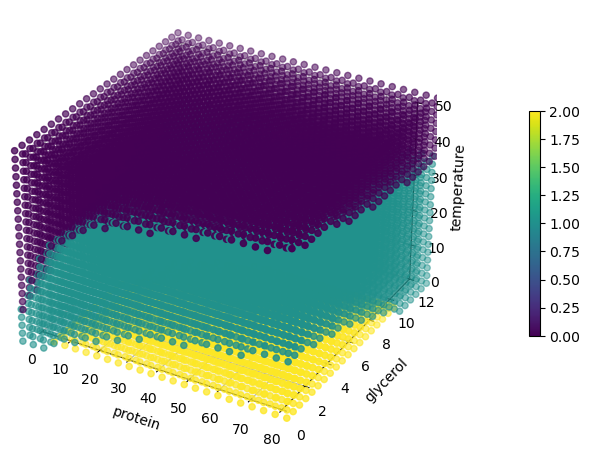

In [36]:
boundary_dataset = xr.load_dataset('250610-extrap_expand_dataset.nc')

fig, ax  = plt.subplots(subplot_kw={"projection":'3d'})

ax = ax
mappable = ax.scatter(
    boundary_dataset["composition"].sel(component='protein').values,
    boundary_dataset["composition"].sel(component='glycerol').values,
    boundary_dataset["composition"].sel(component='temperature').values,
    c=boundary_dataset.labels.values
)
ax.set_xlim(0, 80)
ax.set_ylim(0, 12)
ax.set_zlim(0, 50)
cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, pad=0.15)
ax.set_xlabel("protein")
ax.set_ylabel("glycerol")
ax.set_zlabel("temperature", labelpad=-1)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import xgboost as xgb 
from scipy.stats import entropy

X = boundary_dataset["composition"].values.reshape(-1, 3)
y = boundary_dataset.labels.values 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test)
dall = xgb.DMatrix(X)

params = {
    'objective': 'multi:softprob',
    'num_class': len(set(y)),
    'eval_metric': 'mlogloss',
    'max_depth': 4,
    'eta': 0.1,
    'seed': 42
}

num_rounds = 100
model = xgb.train(params, dtrain, num_rounds)
probs = model.predict(dtest) 
y_pred = probs.argmax(axis=1)
print("Accuracy:", accuracy_score(y_test, y_pred))
score = entropy(model.predict(dall), axis=1)

Accuracy: 0.9008


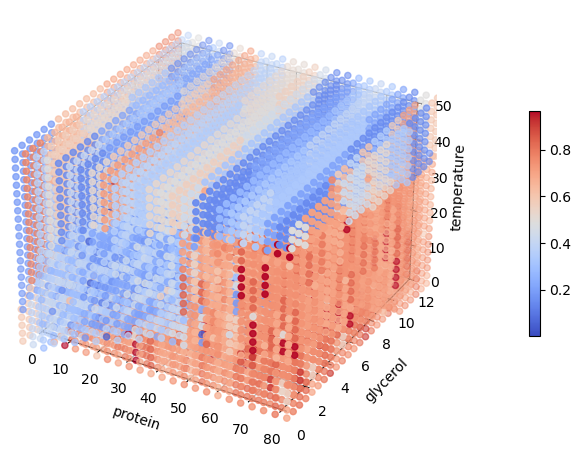

In [62]:
fig, ax  = plt.subplots(subplot_kw={"projection":'3d'})

mappable = ax.scatter(
    boundary_dataset["composition"].sel(component='protein').values,
    boundary_dataset["composition"].sel(component='glycerol').values,
    boundary_dataset["composition"].sel(component='temperature').values,
    c=score,
    cmap='coolwarm'
)
ax.set_xlim(0, 80)
ax.set_ylim(0, 12)
ax.set_zlim(0, 50)
cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, pad=0.15)
ax.set_xlabel("protein")
ax.set_ylabel("glycerol")
ax.set_zlabel("temperature", labelpad=-1)
plt.tight_layout()
plt.show()

In [ ]:
def plot_progress(ds, 
                  design_space_variable, 
                  grid_variable, 
                  design_space_dim, 
                  components,
                  labels_variable,
                  acqf_variable,
                  phase_probability_variable
                  ):
    """Plot cost and entropy in 3D."""
    fig, axs  = plt.subplots(1,3, 
                             figsize=(4*3, 4), 
                             subplot_kw={"projection":'3d'},
                             )

    ax = axs[0]
    ax.scatter(
        ds[design_space_variable].sel({design_space_dim:components[0]}).values,
        ds[design_space_variable].sel({design_space_dim:components[1]}).values,
        ds[design_space_variable].sel({design_space_dim:components[2]}).values,
        c=ds[labels_variable].values
    )
    ax.set_xlim(0, 80)
    ax.set_ylim(0, 12)
    ax.set_zlim(0, 50)

    norm = mcolors.Normalize(vmin=0, vmax=1)
    cmap = plt.get_cmap('coolwarm')
    ax = axs[1]
    mappable = ax.scatter(
        ds[grid_variable].sel({design_space_dim:components[0]}).values,
        ds[grid_variable].sel({design_space_dim:components[1]}).values,
        ds[grid_variable].sel({design_space_dim:components[2]}).values,
        c=ds[acqf_variable].values,
        cmap = cmap,
        norm = norm,
        s=20
    )
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, pad=0.15)
    cbar.set_label(acqf_variable)

    norm = mcolors.Normalize(vmin=0, vmax=1.0)
    cmap = plt.get_cmap("coolwarm")
    ax = axs[2]
    mappable = ax.scatter(
        ds[grid_variable].sel({design_space_dim:components[0]}).values,
        ds[grid_variable].sel({design_space_dim:components[1]}).values,
        ds[grid_variable].sel({design_space_dim:components[2]}).values,
        c=ds[phase_probability_variable].values,
        cmap=cmap,
        norm = norm,
        s=20
    )
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, pad=0.15)
    cbar.set_label(phase_probability_variable)

    for ax in axs:
        ax.set_xlabel(components[0])
        ax.set_ylabel(components[1])
        ax.set_zlabel(components[2], labelpad=-2)
    plt.tight_layout()

    return fig, axs

# Line samples

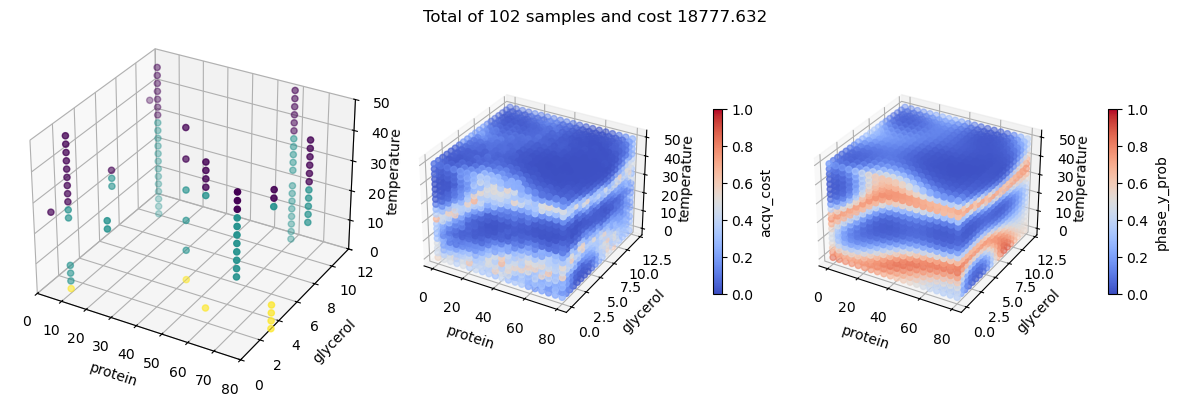

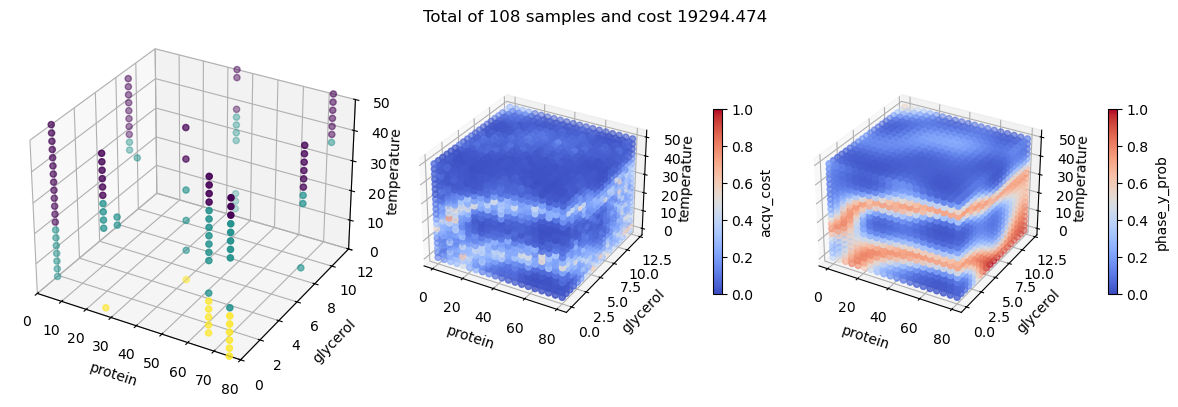

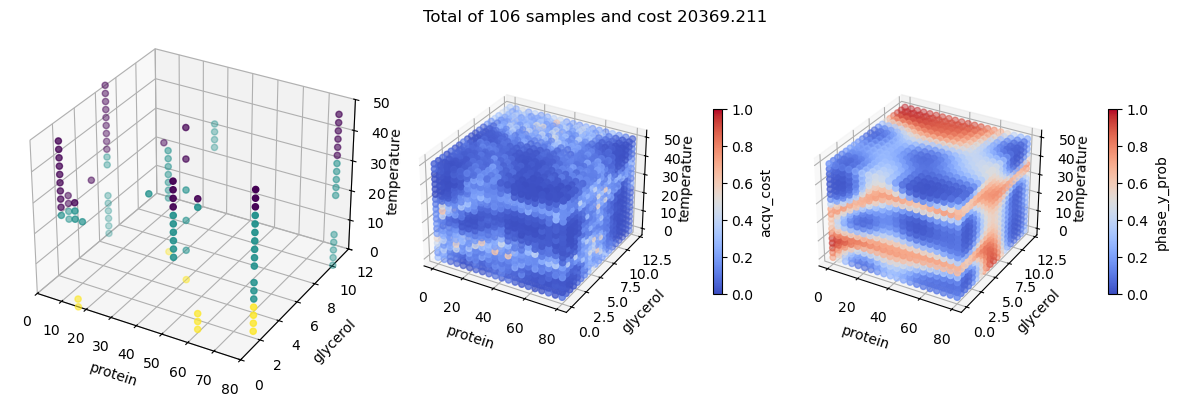

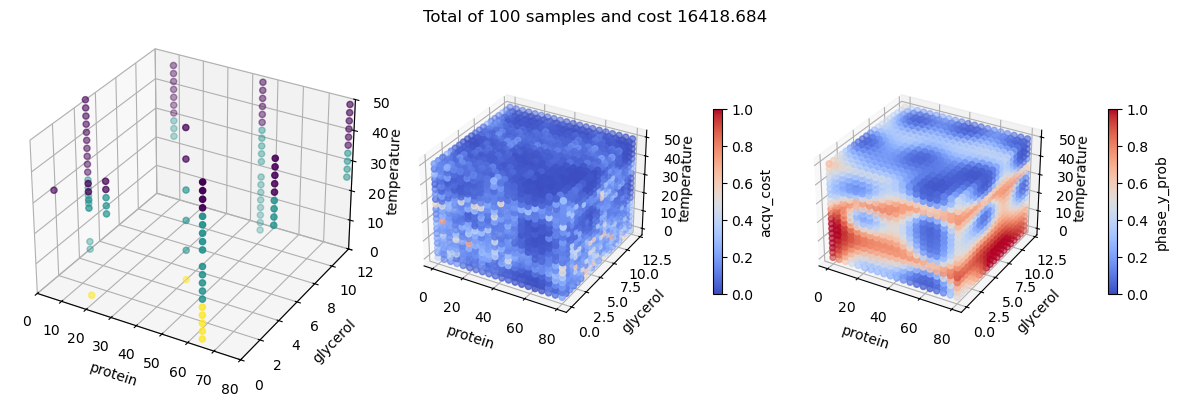

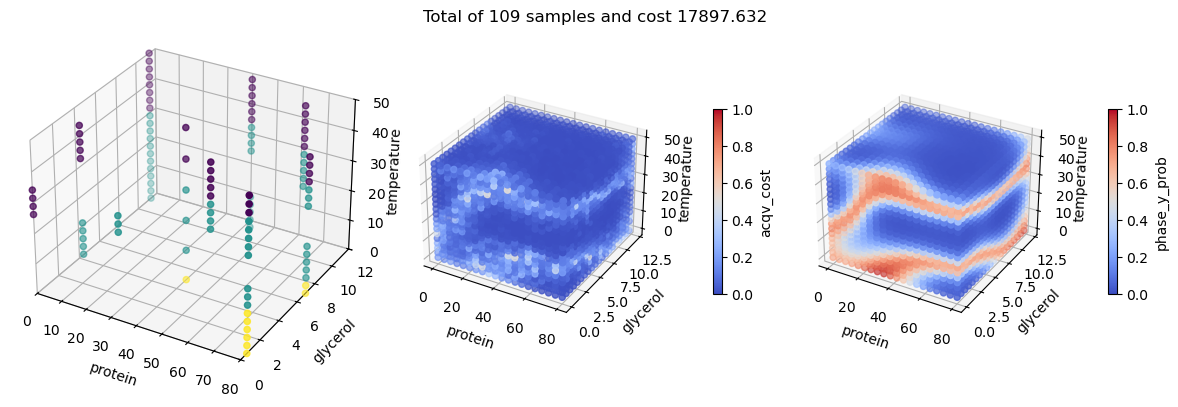

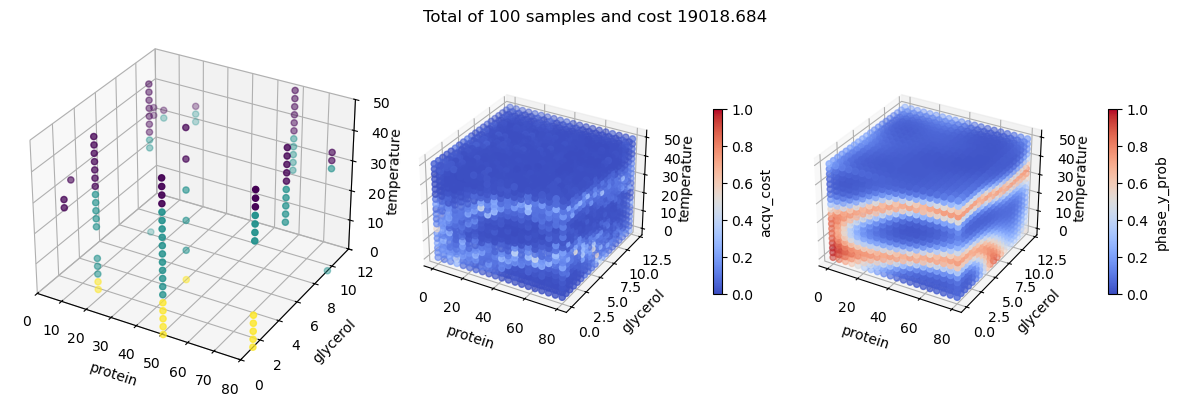

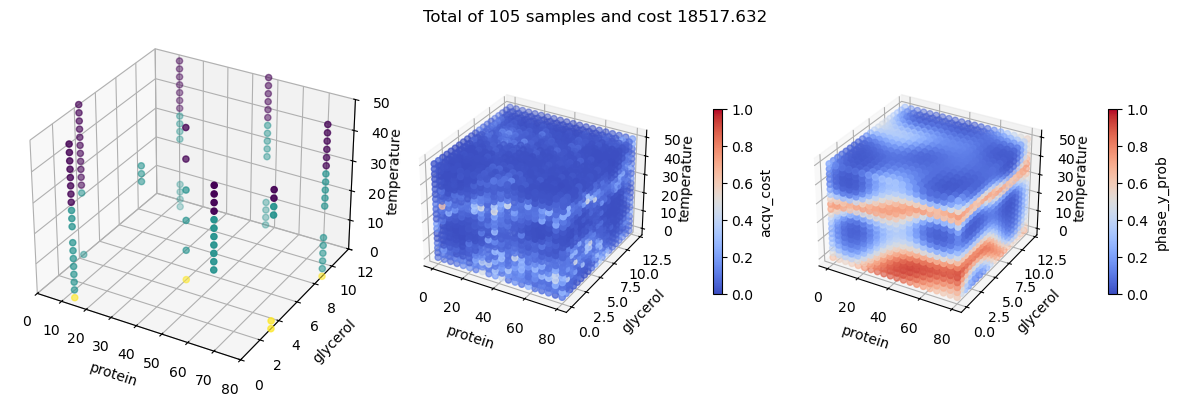

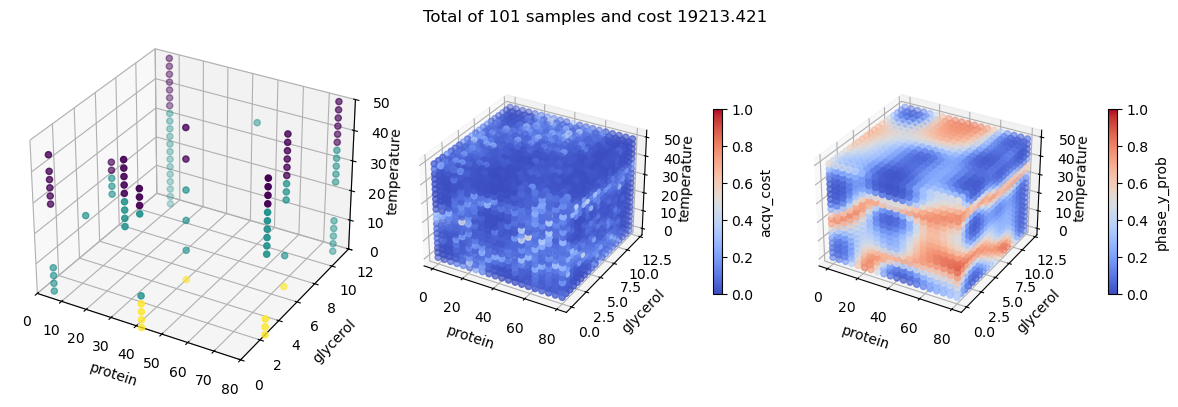

In [ ]:
# Plot line sample expenses 
for i in range(8):
    ds = xr.load_dataset('./results/line_samples/run_%d/ds.nc'%(i+1))
    fig, axs = plot_progress(ds, 
                "design_space", 
                "design_space_grid", 
                "ds_dim", 
                ['protein', 'glycerol', 'temperature'],
                "phases",
                "acqv_cost",
                "phase_y_prob"
                )
    fig.suptitle(f"Total of {len(ds.sample)} samples and cost {ds.expense:.3f}")

    plt.show()


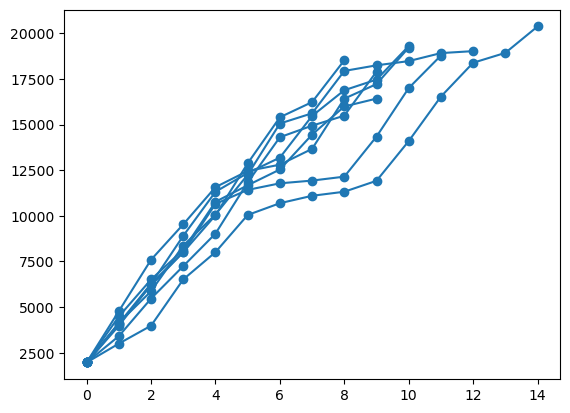

In [ ]:
fig, ax = plt.subplots()
for i in range(8):
    expenses = np.load('./results/line_samples/run_%d/expenses.npy'%(i+1))
    ds = xr.load_dataset('./results/line_samples/run_%d/ds.nc'%(i+1))
    final_expense = ds.expense 
    all_expenses = np.hstack((expenses, final_expense))
    ax.plot(np.arange(len(all_expenses)), all_expenses, 'o-', color="tab:blue")
plt.show()

# Point samples

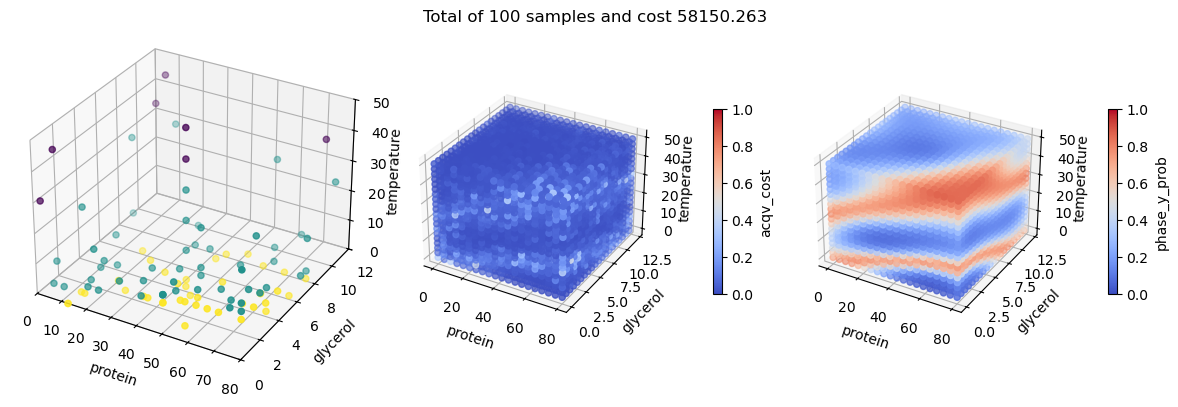

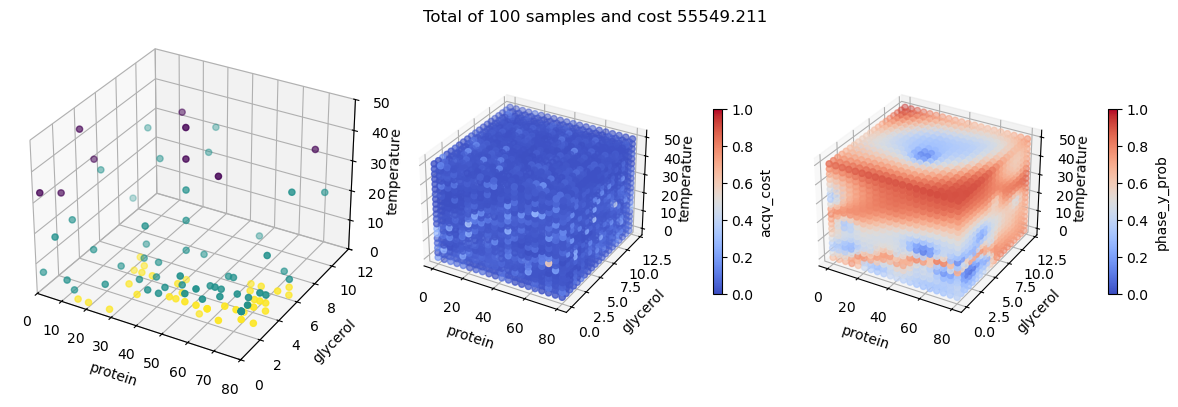

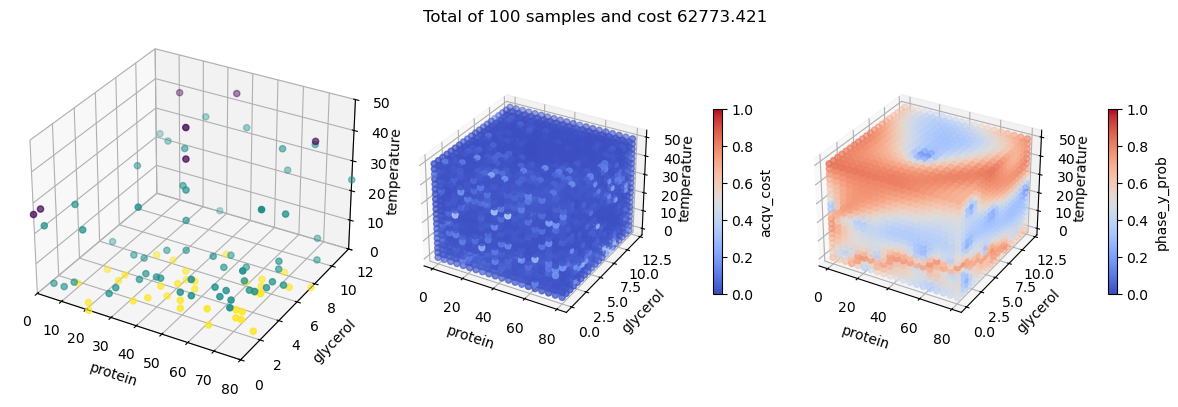

In [ ]:
# Plot point sample expenses 
for i in range(3):
    ds = xr.load_dataset('./results/point_samples/run_%d/ds.nc'%(i+1))
    fig, axs = plot_progress(ds, 
                "design_space", 
                "design_space_grid", 
                "ds_dim", 
                ['protein', 'glycerol', 'temperature'],
                "phases",
                "acqv_cost",
                "phase_y_prob"
                )
    fig.suptitle(f"Total of {len(ds.sample)} samples and cost {ds.expense:.3f}")

    plt.show()


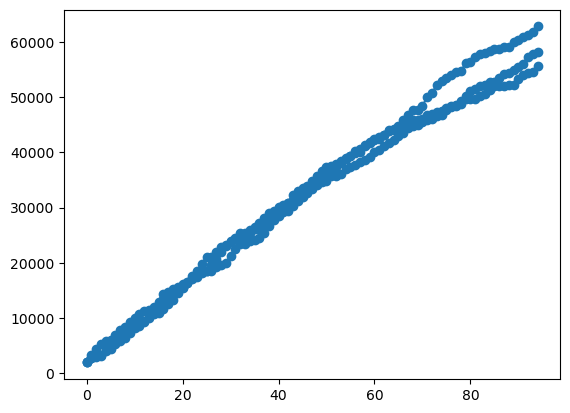

In [ ]:
fig, ax = plt.subplots()
for i in range(3):
    expenses = np.load('./results/point_samples/run_%d/expenses.npy'%(i+1))
    ds = xr.load_dataset('./results/point_samples/run_%d/ds.nc'%(i+1))
    final_expense = ds.expense 
    all_expenses = np.hstack((expenses, final_expense))
    ax.plot(np.arange(len(all_expenses)), all_expenses, 'o-', color="tab:blue")
plt.show()